In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bagheri939/water-potability-csv/water_potability.csv


<div dir="rtl" style="text-align:right"> <h1> بخش اول: پیش پردازش و تحلیل اکتشافی داده ها (EDA) </h1> </div>

<div dir="rtl" style="text-align:right"> <strong>۱. وارد کردن کتابخانه ها</strong></div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

<div dir="rtl" style="text-align:right"> <strong>۲. خواندن مجموعه داده </strong></div>

In [3]:
df = pd.read_csv("/kaggle/input/datasets/bagheri939/water-potability-csv/water_potability.csv")

<div dir="rtl" style="text-align:right"> 
<strong>۳. مشاهده اولیه داده ها </strong></div>
<div dir="rtl" style="text-align:right"> 
در این مرحله ابعاد مجموعه داده، نوع هر ویژگی و آمار اولیه شامل میانگین، انحراف معیار، کمینه، بیشینه و چارک های مختلف بررسی شد. این اطلاعات دید اولیه مناسبی از ساختار داده ها ارائه میکند. 
</div>

In [4]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
df.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [6]:
df.shape

(3276, 10)

In [7]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [9]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


<div dir="rtl" style="text-align:right"> <strong> ۴. بررسی داده های گمشده    </strong></div>

<div dir="rtl" style="text-align:right"> مشاهده میشود برخی ویژگی ها دارای مقادیر گمشده هستند. وجود داده های گمشده میتواند باعث کاهش عملکرد مدل شود؛ بنابراین قبل از آموزش مدل باید این مقادیر مدیریت شوند. </div>

In [10]:
df.isnull().sum()
##مشاهده درصد داده های گمشده 
missing = df.isnull().sum()/len(df)*100
print(missing)

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64


<div dir="rtl" style="text-align:right"> <strong>  ۵. بررسی داده های تکراری   </strong></div>
<div dir="rtl" style="text-align:right"> وجود داده های تکراری میتواند باعث ایجاد سوگیری در مدل شود. بنابراین در صورت وجود، رکوردهای تکراری حذف می‌شوند. اینجا مشاهده می‌شود که داده تکراری وجود ندارد، بنابرین چیزی حذف نمی‌شود. </div>

In [11]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


<div dir="rtl" style="text-align:right"> <strong> ۶. رسم Histogram   </strong></div>
<div dir="rtl" style="text-align:right"> هیستوگرام توزیع هر ویژگی را نمایش میدهد. از طریق این نمودار میتوان تشخیص داد که داده ها نرمال هستند یا خیر، دارای چولگی هستند یا چند قله دارند. </div>

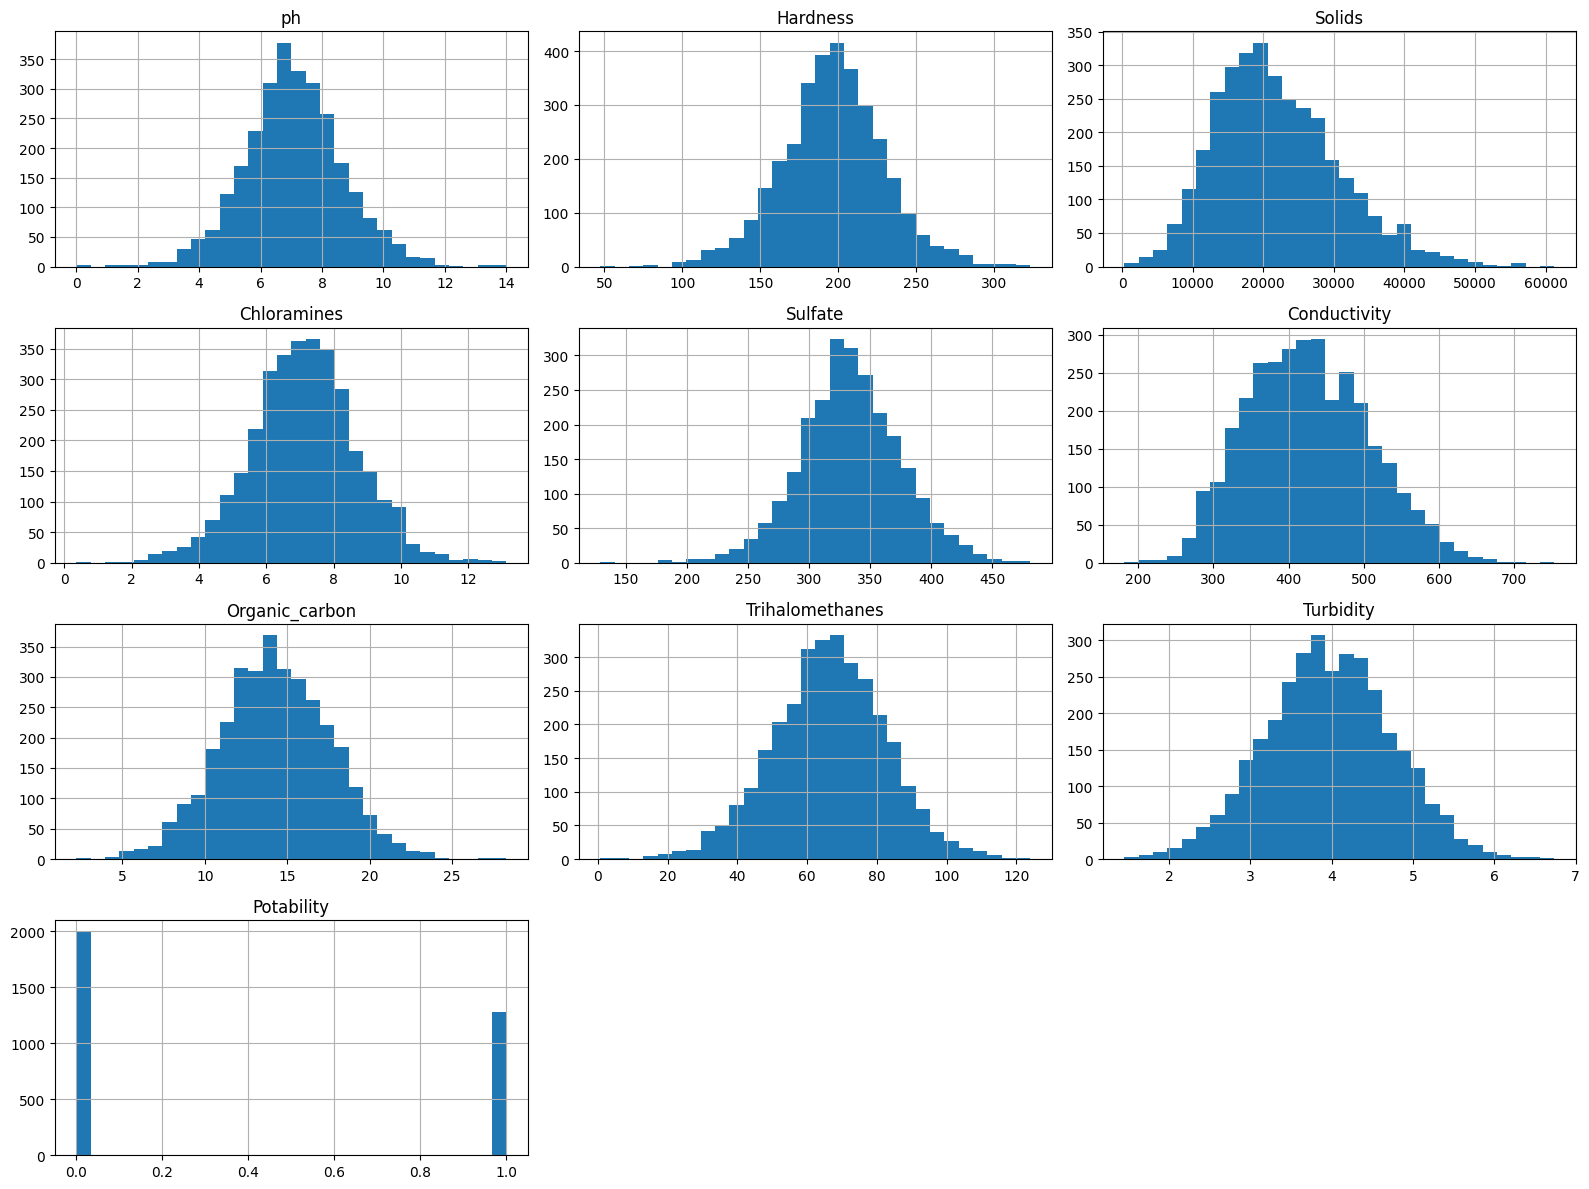

In [12]:
df.hist(figsize=(16,12), bins=30)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right"> <strong>  ۷. Boxplot   </strong></div>
 <div dir="rtl" style="text-align:right"> نمودار Boxplot برای شناسایی داده های پرت رسم شد. مشاهده میشود در برخی ویژگی ها مانند Solids، Sulfate و Trihalomethanes تعداد قابل توجهی داده پرت وجود دارد که میتواند بر عملکرد برخی الگوریتم ها تاثیرگذار باشد.</div>

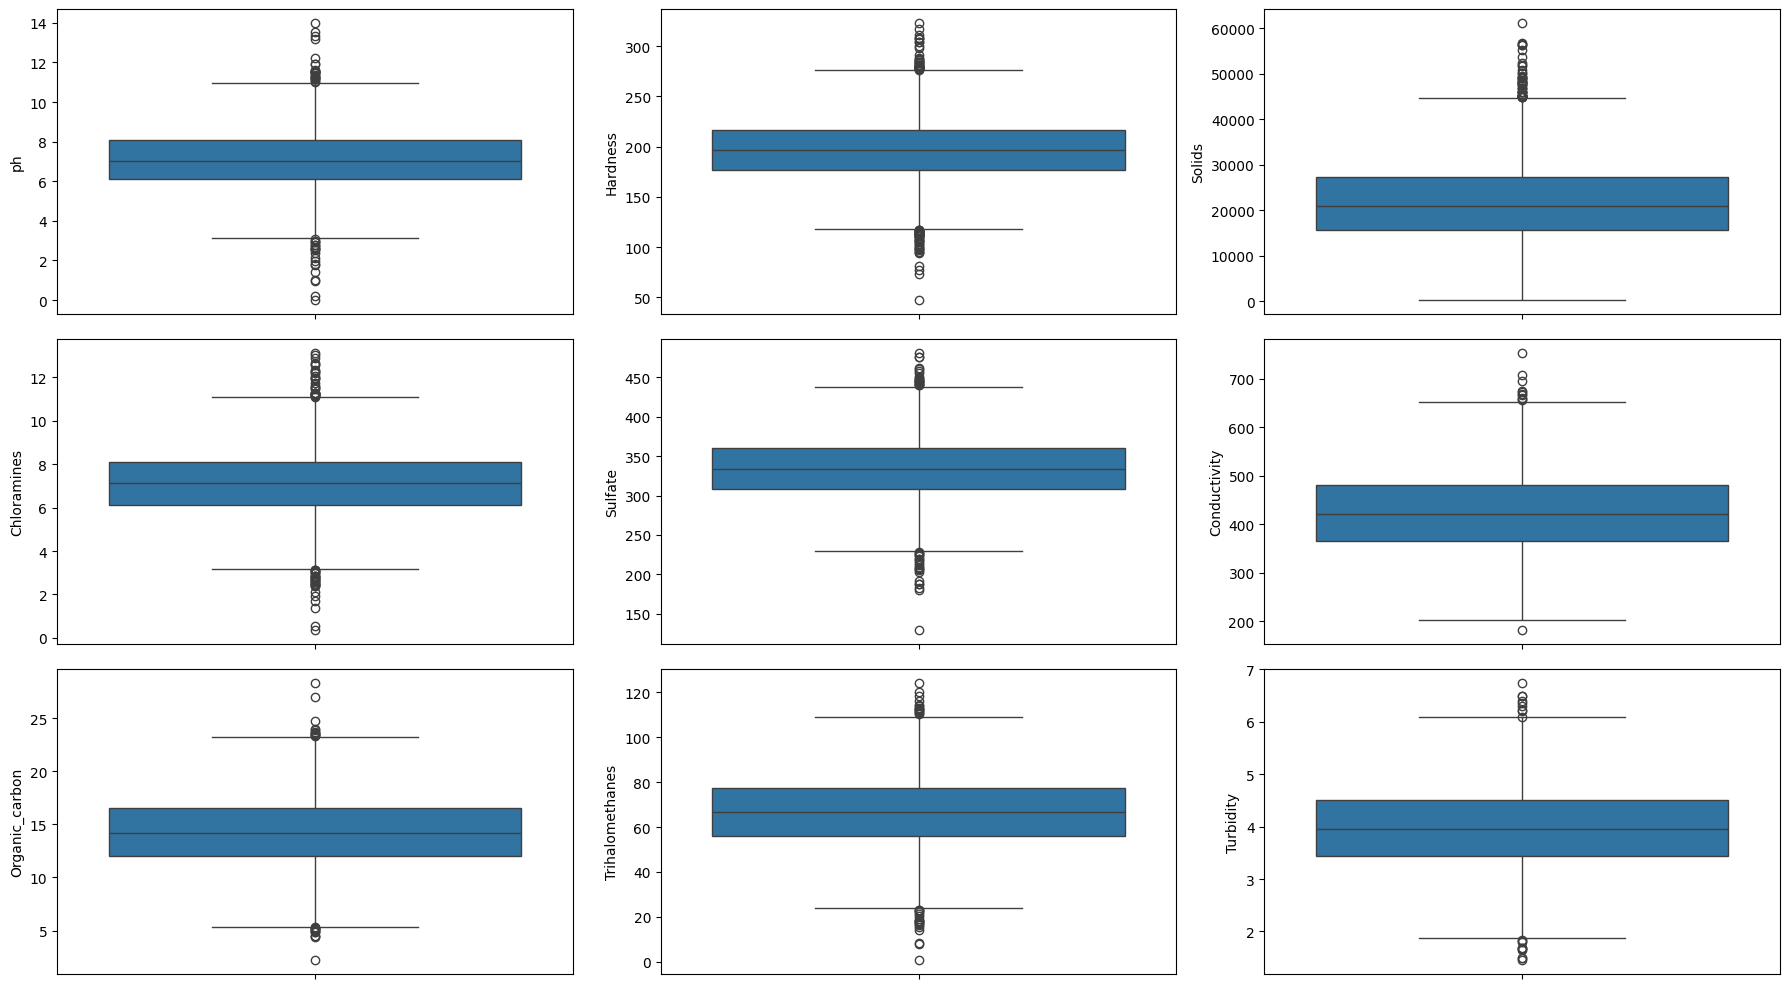

In [13]:
plt.figure(figsize=(18,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right"> <strong>   ۸. بررسی توزیع کلاس ها  </strong></div>
 <div dir="rtl" style="text-align:right"> تعداد نمونه های مربوط به آب قابل شرب و غیر قابل شرب بررسی شد تا مشخص شود آیا عدم توازن بین کلاس ها وجود دارد یا خیر </div>

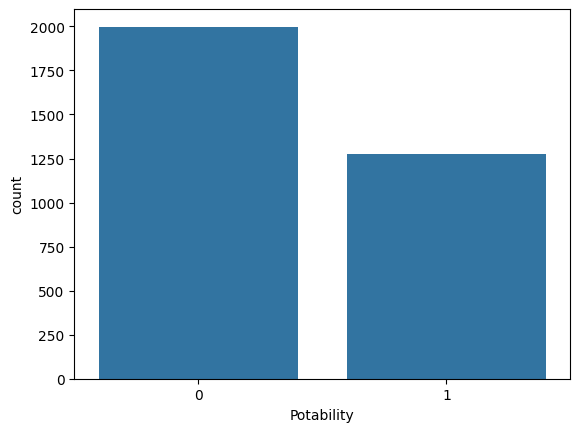

Potability
0    1998
1    1278
Name: count, dtype: int64

In [14]:
sns.countplot(x='Potability', data=df)
plt.show()
df["Potability"].value_counts()

<div dir="rtl" style="text-align:right"> <strong>   ۹. ماتریس همبستگی </strong></div>
 <div dir="rtl" style="text-align:right"> Heatmap میزان همبستگی خطی بین ویژگی ها را نشان میدهد. مشاهده میشود بیشتر ویژگی ها همبستگی ضعیفی با یکدیگر دارند و مقدار ضریب همبستگی آنها کمتر از ۰٫۵ است. بنابراین مشکل هم خطی شدید میان ویژگی ها مشاهده نمیشود.</div>
<div dir="rtl" style="text-align:right">همچنین ویژگی Potability نیز همبستگی بسیار قوی با هیچ یک از ویژگی ها ندارد. این موضوع نشان میدهد که تشخیص قابل شرب بودن آب تنها بر اساس یک ویژگی امکان پذیر نیست و مدل باید رابطه همزمان بین چندین ویژگی را یاد بگیرد. </div>

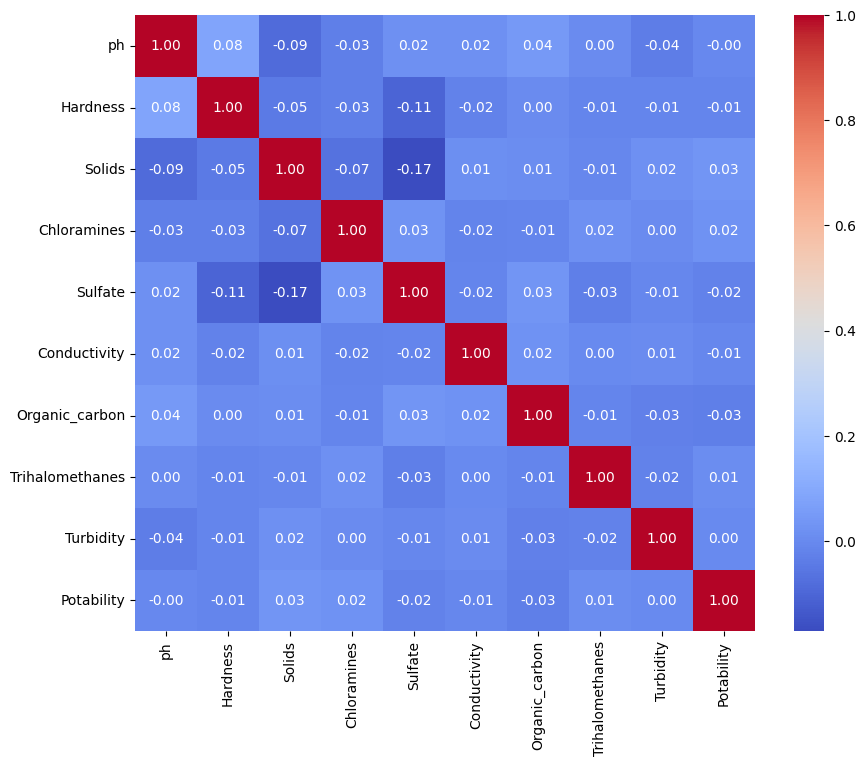

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.show()

<div dir="rtl" style="text-align:right"> <strong>   ۱۰. همبستگی ویژگی ها با متغیر هدف  </strong></div>
 <div dir="rtl" style="text-align:right">ررسی ضرایب همبستگی نشان میدهد که هیچ ویژگی به تنهایی ارتباط خطی قوی با متغیر هدف ندارد. بنابراین استفاده از مدل های یادگیری ماشین برای استخراج روابط پیچیده بین ویژگی ها ضروری است. </div>

In [16]:
corr["Potability"].sort_values(ascending=False)

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

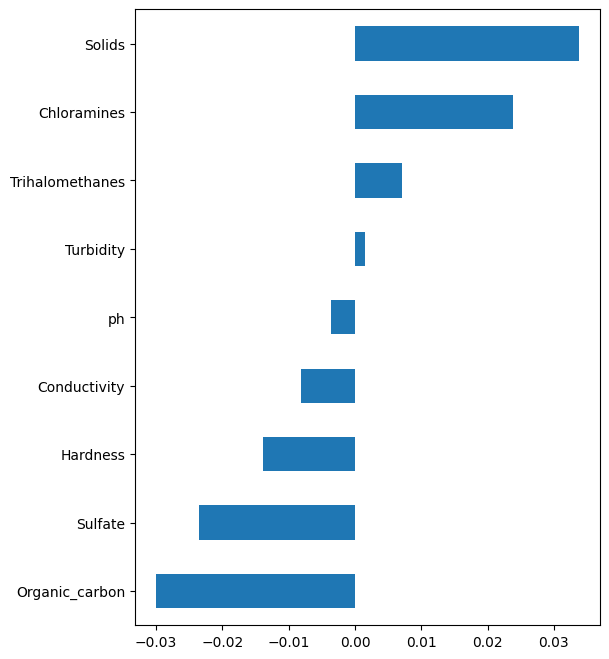

In [17]:
plt.figure(figsize=(6,8))

corr["Potability"].drop("Potability").sort_values().plot(kind="barh")

plt.show()

<div dir="rtl" style="text-align:right"> <strong>   ۱۱. بررسی Scatter Plot  </strong></div>
 <div dir="rtl" style="text-align:right"> نمودارهای پراکندگی نشان میدهند که مرز مشخصی بین دو کلاس وجود ندارد و داده های مربوط به آب سالم و ناسالم تا حد زیادی با یکدیگر همپوشانی دارند. این موضوع نشان میدهد که مسئله طبقه بندی دارای پیچیدگی نسبتا بالایی است. </div>

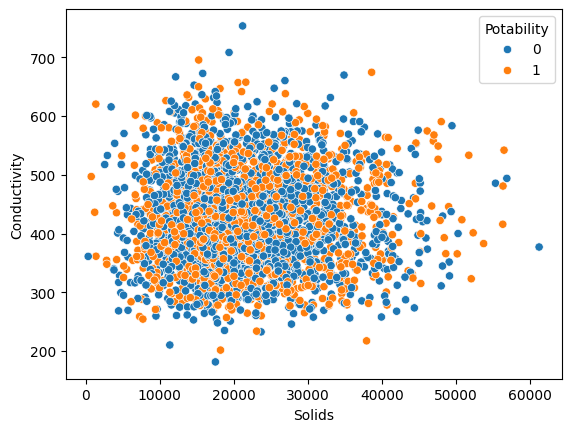

In [18]:
sns.scatterplot(
    data=df,
    x="Solids",
    y="Conductivity",
    hue="Potability"
)

plt.show()

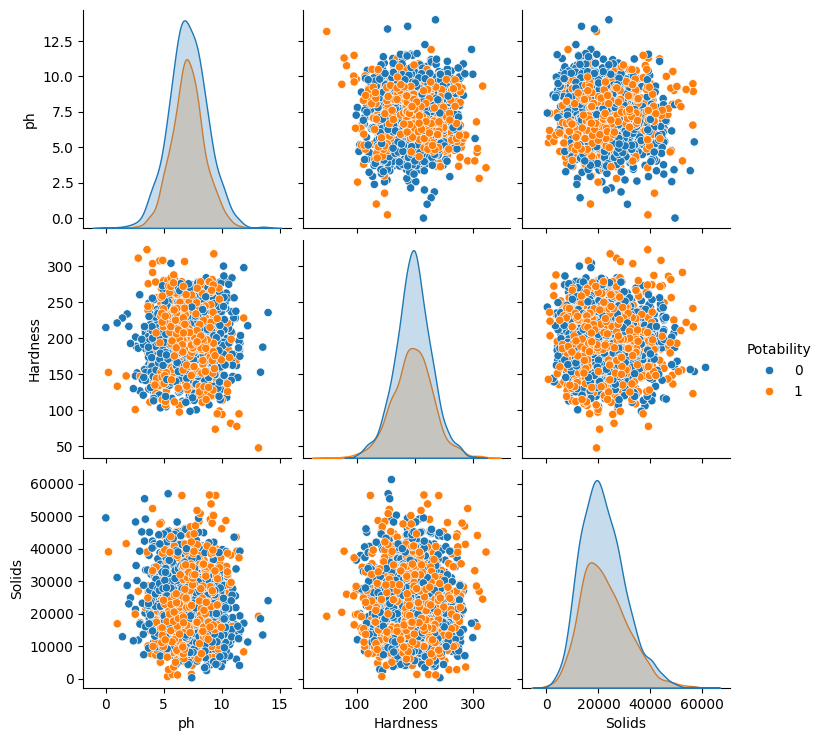

In [19]:
sns.pairplot(df[['ph','Hardness','Solids','Potability']],
             hue='Potability')

<div dir="rtl" style="text-align:right"> <strong>  نتیجه گیری نهایی بخش EDA   </strong></div>
 <div dir="rtl" style="text-align:right"> در مرحله تحلیل اکتشافی داده ها ابتدا ساختار مجموعه داده و ویژگی های آن بررسی شد. سپس وجود داده های گمشده و داده های تکراری ارزیابی گردید. با استفاده از نمودارهای Histogram و Boxplot توزیع ویژگی ها و داده های پرت تحلیل شدند. همچنین با رسم ماتریس همبستگی مشخص شد که وابستگی خطی شدیدی میان ویژگی ها وجود ندارد و هیچ ویژگی به تنهایی توانایی پیش بینی مناسب متغیر هدف را ندارد. علاوه بر این، نمودارهای پراکندگی نشان دادند که دو کلاس دارای همپوشانی قابل توجهی هستند؛ بنابراین برای دستیابی به دقت مناسب، استفاده از مدل های یادگیری ماشین که قادر به یادگیری روابط غیرخطی و ترکیبی میان ویژگی ها باشند، ضروری خواهد بود.</div>

<div dir="rtl" style="text-align:right"> <h2>   مدیریت داده های گمشده (Missing Values) </h2> </div>
<div dir="rtl" style="text-align:right">قبل از پر کردن داده های گمشده، باید به توزیع ویژگی ها توجه کنیم.
در بخش قبل با استفاده از Histogram و Boxplot مشاهده شد که بسیاری از ویژگی ها مانند Solids، Sulfate و Trihalomethanes دارای چولگی (Skewness) و همچنین داده های پرت (Outliers) هستند.
در چنین شرایطی استفاده از میانگین (Mean) انتخاب مناسبی نیست، زیرا میانگین به شدت تحت تاثیر داده های پرت قرار میگیرد. در مقابل، میانه (Median) نسبت به مقادیر پرت مقاوم است و مقدار مرکزی داده ها را بهتر نشان میدهد.
بنابراین در این پروژه از Median Imputation برای جایگزینی مقادیر گمشده استفاده میشود. </div>

<div dir="rtl" style="text-align:right"> <strong>  ۱. بررسی تعداد مقادیر گمشده   </strong></div>

In [20]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

<div dir="rtl" style="text-align:right"> <strong>  ۲. جایگزینی مقادیر گمشده با Median   </strong></div>

In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df[df.columns] = imputer.fit_transform(df)

<div dir="rtl" style="text-align:right"> <strong>   ۳. بررسی مجدد  </strong></div>
 <div dir="rtl" style="text-align:right"> باید خروجی همه ستون ها برابر صفر باشد. </div>

In [22]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

<div dir="rtl" style="text-align:right"> <strong>  تحلیل نتایج    </strong></div>
 <div dir="rtl" style="text-align:right">بررسی اولیه مجموعه داده نشان داد که چندین ویژگی شامل مقادیر گمشده هستند. از آنجا که برخی ویژگی ها دارای توزیع نامتقارن و داده های پرت بودند، استفاده از میانگین میتوانست مقدار جایگزین را تحت تاثیر این مقادیر قرار دهد. به همین دلیل از روش جایگزینی با میانه (Median Imputation) استفاده شد که نسبت به داده های پرت مقاومت بیشتری دارد و مقدار مرکزی مناسب تری برای توزیع های نامتقارن ارائه میکند. پس از انجام این مرحله، تمامی مقادیر گمشده حذف شدند و مجموعه داده برای ادامه فرآیند آماده شد. </div>

<div dir="rtl" style="text-align:right"> <h2>  استانداردسازی ویژگی ها (Feature Scaling)   </h2> </div>
<div dir="rtl" style="text-align:right"> اگر به خروجی describe() نگاه کنیم، مشاهده میشود که دامنه ویژگی ها بسیار متفاوت است.</div>
<div dir="rtl" style="text-align:right">  به عنوان مثال در نتیجه اگر داده ها بدون مقیاس بندی وارد مدل شوند، ویژگی هایی مانند Solids تاثیر بسیار بیشتری نسبت به pH خواهند داشت. به همین دلیل ویژگی ها باید در یک مقیاس یکسان قرار گیرند. </div>

<div dir="rtl" style="text-align:right"> <strong>   در این پروژه بهترین انتخاب StandardScaler است زیرا  </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>میانگین هر ویژگی را صفر میکند.</li>
    <li>انحراف معیار را برابر یک قرار میدهد.</li>
    <li>برای Logistic Regression</li>
    <li>برای SVM</li>
    <li>برای KNN</li>
    <li>برای Neural Network</li>
  
</ul>
</div>
<div dir="rtl" style="text-align:right"> 
تقریبا همیشه عملکرد مناسبی دارد. </div>

<div dir="rtl" style="text-align:right"> <strong>  ۱. جدا کردن ویژگی ها و برچسب   </strong></div>

In [23]:
X = df.drop("Potability", axis=1)

y = df["Potability"]

<div dir="rtl" style="text-align:right"> <strong>  ۲. تقسیم داده ها  </strong></div>
 <div dir="rtl" style="text-align:right"> ابتدا داده ها را تقسیم میکنیم. استفاده از stratify=y باعث میشود نسبت نمونه های دو کلاس در داده های آموزش و آزمون حفظ شود. </div>

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<div dir="rtl" style="text-align:right"> <strong>  ۳. اعمال StandardScaler   </strong></div>
 <div dir="rtl" style="text-align:right"> روی داده های آموزش از fit_transform() استفاده میشود ولی روی داده های آزمون فقط transform() اعمال میشود تا از نشت اطلاعات (Data Leakage) جلوگیری شود. </div>

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

<div dir="rtl" style="text-align:right"> <strong>   ۴. بررسی نتیجه  </strong></div>

In [26]:
X_train_scaled.mean(axis=0)

array([ 7.25458709e-17, -2.12213622e-16,  4.61039180e-17,  6.76642796e-16,
        3.23405425e-16,  1.08344207e-15, -8.67838456e-17, -1.01699819e-17,
       -2.19671609e-16])

In [27]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

<div dir="rtl" style="text-align:right"> <strong>    تحلیل نتایج </strong></div>
 <div dir="rtl" style="text-align:right"> از آنجا که دامنه مقادیر ویژگی های مختلف بسیار متفاوت بود، از استانداردسازی ویژگی ها استفاده شد. در این روش، میانگین هر ویژگی به صفر و انحراف معیار آن به یک تبدیل میشود. این کار باعث میشود هیچ ویژگی تنها به دلیل بزرگ بودن مقیاس خود بر سایر ویژگی ها غلبه نکند. استانداردسازی تنها بر روی داده های آموزش برازش داده شد و سپس همان پارامترها برای تبدیل داده های آزمون مورد استفاده قرار گرفت تا از نشت اطلاعات جلوگیری شود. </div>

<div dir="rtl" style="text-align:right"> <h1>   بخش دوم: یادگیری با نظارت (Classification)  </h1> </div>

<div dir="rtl" style="text-align:right"> <strong>   ۱. تقسیم داده ها  </strong></div>
 <div dir="rtl" style="text-align:right">ابتدا داده ها به دو بخش آموزش و آزمون تقسیم شدند.</div>
 <div dir="rtl" style="text-align:right">برای ارزیابی صحیح مدل ها، مجموعه داده به دو بخش آموزش و آزمون با نسبت ۸۰ به ۲۰ تقسیم شد. از پارامتر stratify=y استفاده شد تا نسبت کلاس های قابل شرب و غیرقابل شرب در هر دو مجموعه حفظ شود. این کار از ایجاد سوگیری در فرآیند آموزش و ارزیابی جلوگیری میکند. </div>

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

<div dir="rtl" style="text-align:right"> <strong>   ۲. استانداردسازی  </strong></div>

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div dir="rtl" style="text-align:right"> <h2>  رگرسیون منطقی (Logistic Regression)   </h2> </div>
<div dir="rtl" style="text-align:right">
رگرسیون منطقی یک مدل خطی برای مسائل طبقه بندی دودویی است که احتمال تعلق هر نمونه به کلاس مثبت را با استفاده از تابع سیگموید محاسبه میکند. این مدل پایه مناسبی برای مقایسه عملکرد سایر الگوریتم ها محسوب میشود. </div>


<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل   </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li> solver='lbfgs' یکی از پایدارترین حل کننده ها برای مسائل طبقه بندی دودویی است. </li>
    <li> max_iter=1000 احتمال همگرا نشدن مدل را کاهش میدهد. </li>
    <li> random_state=42 قابلیت تکرار نتایج را تضمین میکند. </li>
  
</ul>
</div>

In [30]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

<div dir="rtl" style="text-align:right"> <strong>  پیش بینی   </strong></div>


In [31]:
y_pred_lr = log_reg.predict(X_test_scaled)

<div dir="rtl" style="text-align:right"> <h2>  K-Nearest Neighbors (KNN)   </h2></div>
 <div dir="rtl" style="text-align:right"> الگوریتم KNN هیچ مدلی را به صورت صریح یاد نمیگیرد و طبقه نمونه جدید را بر اساس نزدیک ترین نمونه های آموزشی تعیین میکند. از آنجا که این الگوریتم مبتنی بر فاصله است، استانداردسازی ویژگی ها قبل از آموزش ضروری است. </div>

<div dir="rtl" style="text-align:right"> <strong> آموزش مدل  </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li> n_neighbors=7 معمولا تعادل مناسبی بین بیش برازش و کم برازش ایجاد میکند. </li>
    <li> weights='distance' باعث میشود همسایه های نزدیک تر تاثیر بیشتری داشته باشند. </li>
    <li> p=2 یعنی استفاده از فاصله اقلیدسی. </li>
</ul>
</div>

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    p=2
)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [33]:
y_pred_knn = knn.predict(X_test_scaled)

<div dir="rtl" style="text-align:right"> <h2> ماشین بردار پشتیبان (SVM)  </h2></div>
<div dir="rtl" style="text-align:right">ماشین بردار پشتیبان با یافتن بهترین مرز تصمیم میان کلاس ها عمل میکند. استفاده از هسته RBF باعث میشود مدل بتواند روابط غیرخطی میان ویژگی ها را نیز یاد بگیرد. این الگوریتم نسبت به مقیاس ویژگی ها حساس است؛ بنابراین استفاده از StandardScaler اهمیت زیادی دارد. </div>

<div dir="rtl" style="text-align:right"> <strong> آموزش مدل  </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>kernel='rbf' امکان یادگیری روابط غیرخطی را فراهم میکند.</li>
    <li>gamma='scale' مقدار پیشنهادی Scikit-Learn است.</li>
    <li> C=1.0 تعادل مناسبی میان تعمیم پذیری و دقت ایجاد میکند.</li>
</ul>
</div>

In [34]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [35]:
y_pred_svm = svm.predict(X_test_scaled)

<div dir="rtl" style="text-align:right"> <h2>  درخت تصمیم (Decision Tree)   </h2> </div>
<div dir="rtl" style="text-align:right"> برخلاف KNN و SVM، درخت تصمیم از مقایسه مقادیر ویژگی ها استفاده میکند و وابسته به فاصله نیست؛ بنابراین استانداردسازی تاثیری بر عملکرد آن ندارد و میتوان از داده های اصلی استفاده کرد. </div>

<div dir="rtl" style="text-align:right"> 
درخت تصمیم فضای ویژگی ها را به صورت بازگشتی تقسیم میکند و قوانین تصمیم گیری قابل تفسیر تولید میکند. محدود کردن عمق درخت و حداقل تعداد نمونه های هر گره به کاهش بیش برازش و بهبود توان تعمیم مدل کمک میکند.
 </div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>max_depth=6 از رشد بیش از حد درخت جلوگیری میکند.</li>
    <li>min_samples_split=10 احتمال بیش برازش را کاهش میدهد. </li>
    <li>min_samples_leaf=5 باعث ایجاد برگ های پایدارتر میشود. </li>
</ul>
</div>

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [37]:
y_pred_dt = dt.predict(X_test)

<div dir="rtl" style="text-align:right"> <h2>  Gradient Boosting   </h2> </div>
<div dir="rtl" style="text-align:right"> Gradient Boosting مجموعه ای از درخت های تصمیم را به صورت ترتیبی آموزش میدهد. هر درخت جدید تلاش میکند خطاهای مدل قبلی را اصلاح کند. این الگوریتم معمولا دقت بالاتری نسبت به یک درخت تصمیم منفرد دارد.</div>

<div dir="rtl" style="text-align:right"> <strong> آموزش مدل  </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>n_estimators=100 تعداد مناسبی از درخت ها برای شروع است.</li>
    <li>learning_rate=0.1 سرعت یادگیری را کنترل میکند. </li>
    <li>max_depth=3 باعث جلوگیری از بیش برازش میشود. </li>
</ul>
</div>

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [39]:
y_pred_gb = gb.predict(X_test)

<div dir="rtl" style="text-align:right"> <h2> AdaBoost (Adaptive Boosting)    </h2> </div>
<div dir="rtl" style="text-align:right"> <strong>AdaBoost با ترکیب تعداد زیادی یادگیرنده ضعیف، یک مدل قوی ایجاد میکند. در هر مرحله وزن نمونه هایی که اشتباه طبقه بندی شده اند افزایش می یابد تا مدل روی آنها تمرکز بیشتری داشته باشد.     </strong></div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>
n_estimators=100 تعداد مناسبی از یادگیرنده های ضعیف ایجاد میکند.</li>
    <li>learning_rate=1.0 مقدار پیش فرض و مناسب برای شروع است. </li>

</ul>
</div>

In [40]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [41]:
y_pred_ada = ada.predict(X_test)

<div dir="rtl" style="text-align:right"> <h2>  Random Forest   </h2> </div>
<div dir="rtl" style="text-align:right"> <strong>  Random Forest مجموعه ای از درخت های تصمیم است که هر درخت روی نمونه های تصادفی و زیرمجموعه ای از ویژگی ها آموزش میبیند. این روش معمولا نسبت به یک درخت تصمیم دقت بیشتر و بیش برازش کمتری دارد.   </strong></div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>n_estimators=200 باعث پایداری بیشتر مدل میشود.</li>
    <li> max_depth=10 از رشد بیش از حد درخت ها جلوگیری میکند.</li>
    <li>
n_jobs=-1 از تمام هسته های پردازنده استفاده میکند. </li>
</ul>
</div>

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [43]:
y_pred_rf = rf.predict(X_test)

<div dir="rtl" style="text-align:right"> <h2>  شبکه عصبی پرسپترون چندلایه (MLP Classifier)   </h2> </div>
<div dir="rtl" style="text-align:right"> <strong> پرسپترون چندلایه یک شبکه عصبی پیشخور است که میتواند روابط غیرخطی پیچیده بین ویژگی ها را یاد بگیرد. از آنجا که این الگوریتم نسبت به مقیاس ویژگی ها حساس است، آموزش آن روی داده های استانداردشده انجام شد.    </strong></div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>دو لایه مخفی (100,50) توانایی یادگیری روابط پیچیده را افزایش میدهد.</li>
    <li>relu سریع ترین و پرکاربردترین تابع فعال سازی است. </li>
    <li>adam یکی از بهترین بهینه سازها برای این نوع شبکه ها است. </li>
    <li>max_iter=1000 احتمال همگرایی کامل مدل را افزایش میدهد. </li>
</ul>
</div>

In [44]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [45]:
y_pred_mlp = mlp.predict(X_test_scaled)

<div dir="rtl" style="text-align:right"> <h2> Extra Trees (Extremely Randomized Trees)   </h2> </div>
<div dir="rtl" style="text-align:right"> <strong>Extra Trees شباهت زیادی به Random Forest دارد، با این تفاوت که علاوه بر انتخاب تصادفی ویژگی ها، آستانه تقسیم هر گره نیز به صورت تصادفی انتخاب میشود. این تصادفی سازی بیشتر معمولا باعث کاهش واریانس مدل و افزایش سرعت آموزش میشود.     </strong></div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>
<div dir="rtl" style="text-align:right">
<ul>
    <li>n_estimators=200 عملکرد مدل را پایدارتر میکند.</li>
    <li>
محدود کردن عمق درخت ها احتمال بیش برازش را کاهش میدهد. </li>
</ul>
</div>

In [46]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                     n_estimators=200, n_jobs=-1, random_state=42)

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [47]:
y_pred_et = et.predict(X_test)

<div dir="rtl" style="text-align:right"> <h2>  Gaussian Naive Bayes   </h2> </div>
<div dir="rtl" style="text-align:right"> <strong> Gaussian Naive Bayes بر اساس قضیه بیز عمل میکند و فرض میکند ویژگی ها نسبت به یکدیگر مستقل هستند. همچنین فرض میشود توزیع هر ویژگی در هر کلاس از توزیع نرمال پیروی میکند. با وجود ساده بودن این فرضیات، این الگوریتم در بسیاری از مسائل طبقه بندی عملکرد قابل قبولی دارد و سرعت آموزش بسیار بالایی دارد.    </strong></div>

<div dir="rtl" style="text-align:right"> <strong>  آموزش مدل </strong></div>

In [48]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

GaussianNB()

<div dir="rtl" style="text-align:right"> <strong>   پیش بینی  </strong></div>

In [49]:
y_pred_gnb = gnb.predict(X_test_scaled)

<div dir="rtl" style="text-align:right"> <h1>  بخش سوم: ارزیابی و مقایسه مدل ها   </h1> </div>
<div dir="rtl" style="text-align:right"> <strong>  ۱. اضافه کردن کتابخانه‌ها   </strong></div>

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

<div dir="rtl" style="text-align:right"> <strong>  ۲. قرار دادن تمام مدل ها در یک دیکشنری  </strong></div>

In [51]:
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "KNN": (knn, X_test_scaled),
    "SVM": (svm, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "Gradient Boosting": (gb, X_test),
    "AdaBoost": (ada, X_test),
    "Random Forest": (rf, X_test),
    "MLP": (mlp, X_test_scaled),
    "Extra Trees": (et, X_test),
    "Gaussian NB": (gnb, X_test_scaled)
}

<div dir="rtl" style="text-align:right"> <strong>  ۳. محاسبه معیارهای ارزیابی   </strong></div>

In [52]:
results = []

for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000
1,KNN,0.591463,0.461538,0.281250,0.349515
2,SVM,0.670732,0.704082,0.269531,0.389831
3,Decision Tree,0.646341,0.611111,0.257812,0.362637
4,Gradient Boosting,0.652439,0.642857,0.246094,0.355932
5,AdaBoost,0.618902,0.600000,0.070312,0.125874
6,Random Forest,0.669207,0.767123,0.218750,0.340426
7,MLP,0.609756,0.500000,0.410156,0.450644
8,Extra Trees,0.643293,0.866667,0.101562,0.181818
9,Gaussian NB,0.614329,0.516129,0.187500,0.275072


<div dir="rtl" style="text-align:right"> <strong>   ۴. محاسبه معیارهای ارزیابی  </strong></div>

In [53]:
results = []

for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000
1,KNN,0.591463,0.461538,0.281250,0.349515
2,SVM,0.670732,0.704082,0.269531,0.389831
3,Decision Tree,0.646341,0.611111,0.257812,0.362637
4,Gradient Boosting,0.652439,0.642857,0.246094,0.355932
5,AdaBoost,0.618902,0.600000,0.070312,0.125874
6,Random Forest,0.669207,0.767123,0.218750,0.340426
7,MLP,0.609756,0.500000,0.410156,0.450644
8,Extra Trees,0.643293,0.866667,0.101562,0.181818
9,Gaussian NB,0.614329,0.516129,0.187500,0.275072


<div dir="rtl" style="text-align:right"> <strong>  ۵. مرتب سازی نتایج   </strong></div>

In [54]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-score
2,SVM,0.670732,0.704082,0.269531,0.389831
6,Random Forest,0.669207,0.767123,0.218750,0.340426
4,Gradient Boosting,0.652439,0.642857,0.246094,0.355932
3,Decision Tree,0.646341,0.611111,0.257812,0.362637
8,Extra Trees,0.643293,0.866667,0.101562,0.181818
5,AdaBoost,0.618902,0.600000,0.070312,0.125874
9,Gaussian NB,0.614329,0.516129,0.187500,0.275072
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000
7,MLP,0.609756,0.500000,0.410156,0.450644
1,KNN,0.591463,0.461538,0.281250,0.349515


<div dir="rtl" style="text-align:right"> <strong>  ۶. گزارش کامل هر مدل   </strong></div>

In [55]:
for name, (model, X_eval) in models.items():

    print("="*60)
    print(name)

    y_pred = model.predict(X_eval)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.61      1.00      0.76       400
         1.0       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656

KNN
              precision    recall  f1-score   support

         0.0       0.63      0.79      0.70       400
         1.0       0.46      0.28      0.35       256

    accuracy                           0.59       656
   macro avg       0.55      0.54      0.53       656
weighted avg       0.57      0.59      0.56       656

SVM
              precision    recall  f1-score   support

         0.0       0.66      0.93      0.77       400
         1.0       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.66      0.96      0.78       400
         1.0       0.77      0.22      0.34       256

    accuracy                           0.67       656
   macro avg       0.71      0.59      0.56       656
weighted avg       0.70      0.67      0.61       656

MLP
              precision    recall  f1-score   support

         0.0       0.66      0.74      0.70       400
         1.0       0.50      0.41      0.45       256

    accuracy                           0.61       656
   macro avg       0.58      0.57      0.57       656
weighted avg       0.60      0.61      0.60       656

Extra Trees
              precision    recall  f1-score   support

         0.0       0.63      0.99      0.77       400
         1.0       0.87      0.10      0.18       256

    accuracy                           0.64       656
   macro avg       0.75      0.55      0.48       656
weighted avg       0.72      0.64      0.54       656

Gau

<div dir="rtl" style="text-align:right"> <h3>  رسم ماتریس درهم ریختگی   </h3></div> 
<div dir="rtl" style="text-align:right"> ماتریس درهم ریختگی نشان میدهد هر مدل چه تعداد نمونه را به درستی و چه تعداد را به اشتباه طبقه بندی کرده است. قطر اصلی ماتریس بیانگر پیش بینی های صحیح بوده و مقادیر خارج از قطر نشان دهنده خطاهای طبقه بندی هستند. با بررسی این ماتریس میتوان تشخیص داد که مدل در شناسایی کدام کلاس عملکرد ضعیف تری دارد.</div>

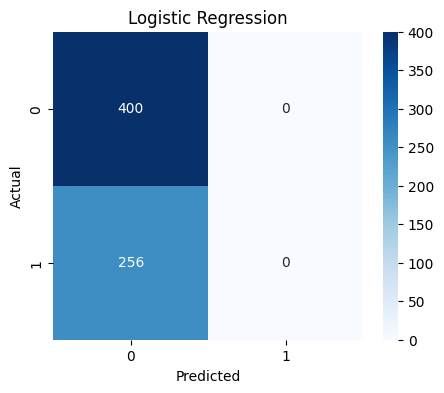

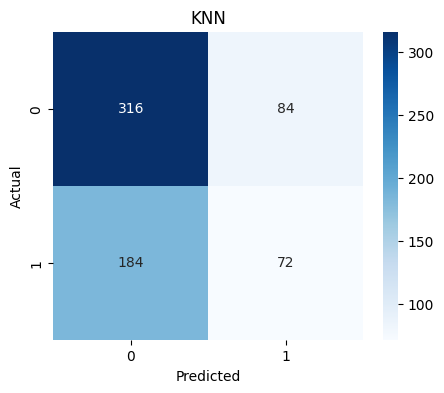

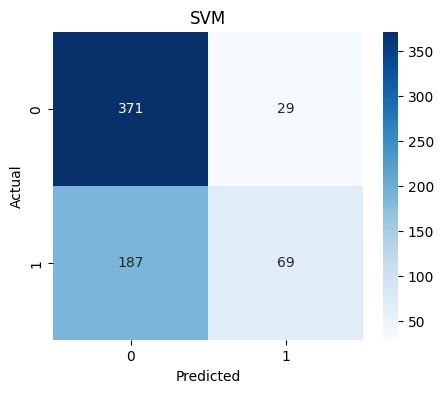

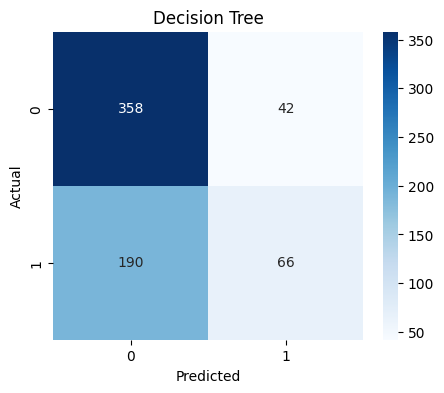

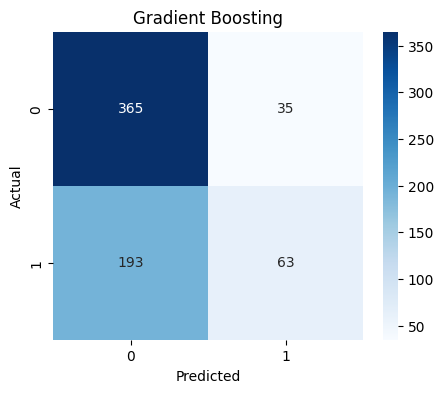

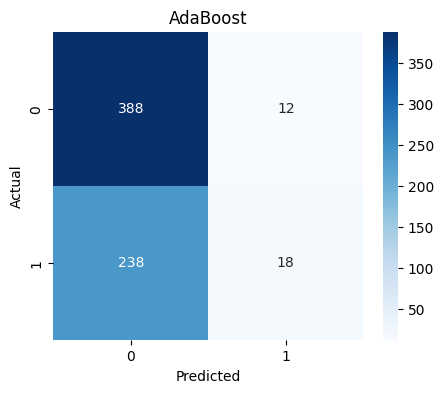

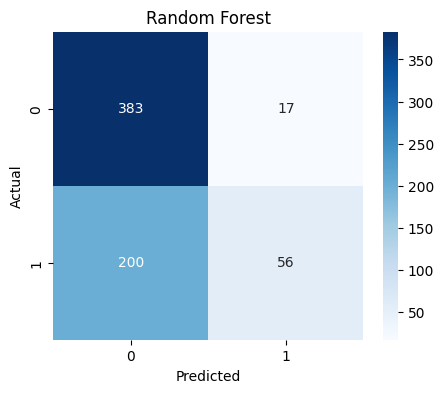

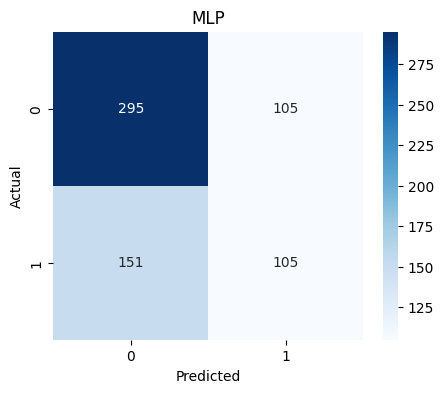

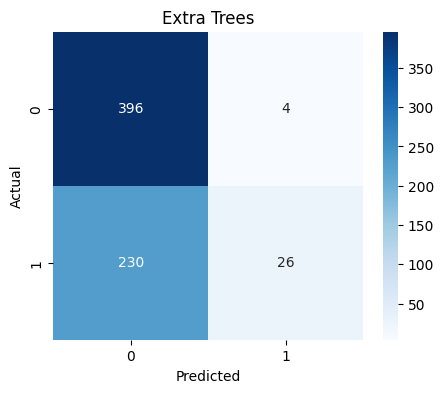

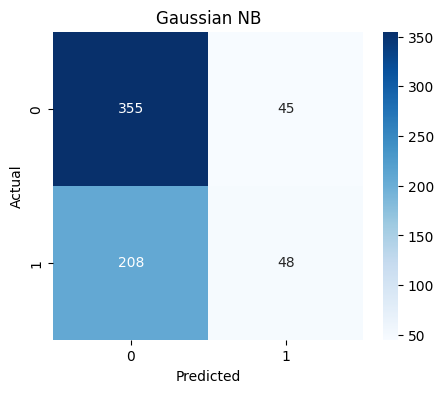

In [56]:
for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

<div dir="rtl" style="text-align:right"> <h3>  نمودار مقایسه Accuracy    </h3></div>

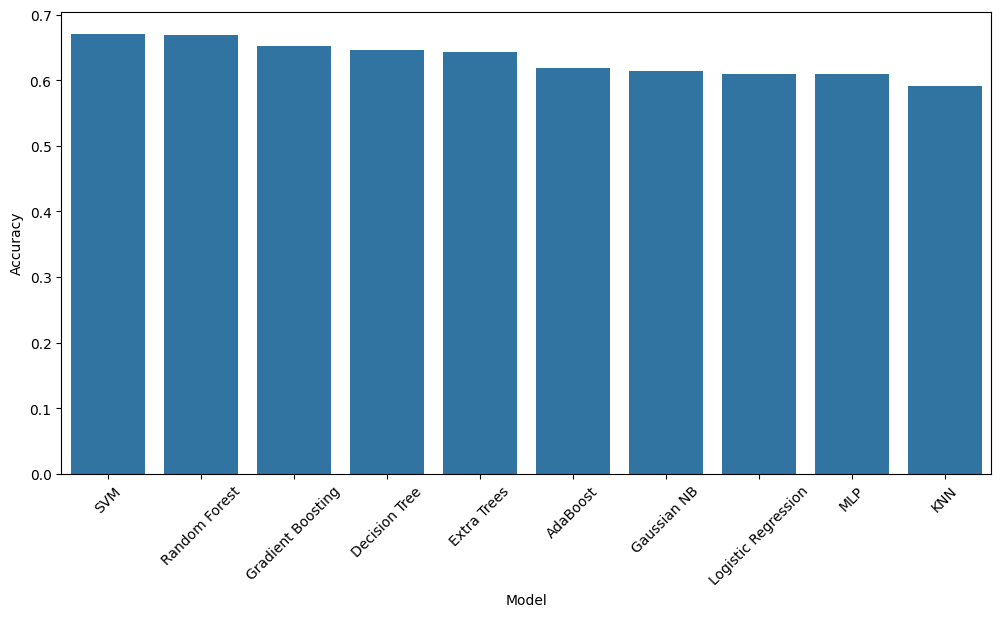

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.show()

<div dir="rtl" style="text-align:right"> <h3>  مقایسه Precision   </h3></div>

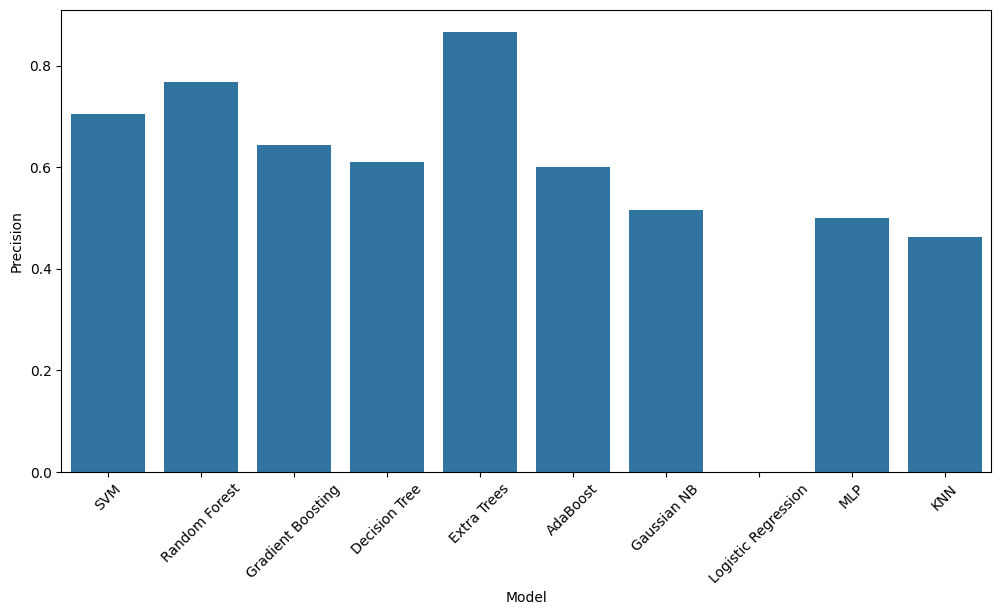

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.xticks(rotation=45)

plt.show()

<div dir="rtl" style="text-align:right"> <h3> مقایسه Recall    </h3> </div>

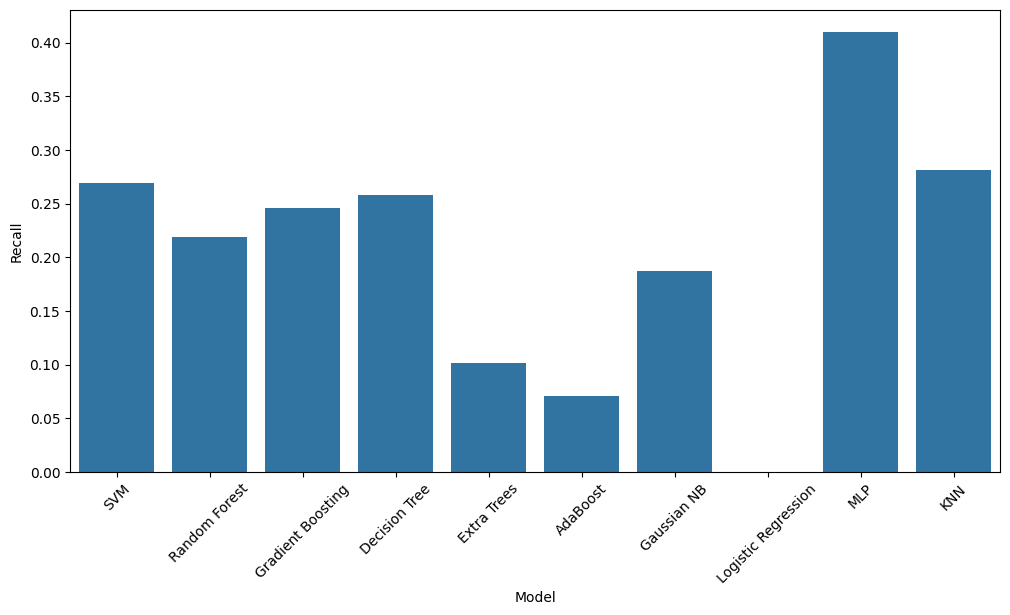

In [59]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.xticks(rotation=45)

plt.show()

<div dir="rtl" style="text-align:right"> <h3> مقایسه F1-score    </h3> </div>

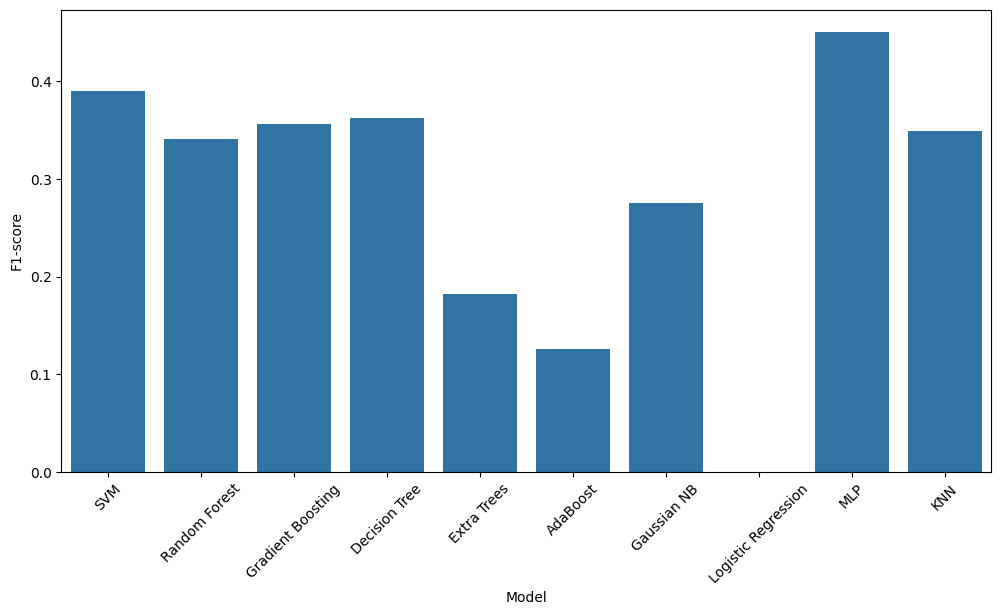

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-score"
)

plt.xticks(rotation=45)

plt.show()

<div dir="rtl" style="text-align:right"> <h3> جدول نهایی    </h3> </div>

In [61]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
2,SVM,0.6707,0.7041,0.2695,0.3898
6,Random Forest,0.6692,0.7671,0.2188,0.3404
4,Gradient Boosting,0.6524,0.6429,0.2461,0.3559
3,Decision Tree,0.6463,0.6111,0.2578,0.3626
8,Extra Trees,0.6433,0.8667,0.1016,0.1818
5,AdaBoost,0.6189,0.6000,0.0703,0.1259
9,Gaussian NB,0.6143,0.5161,0.1875,0.2751
0,Logistic Regression,0.6098,0.0000,0.0000,0.0000
7,MLP,0.6098,0.5000,0.4102,0.4506
1,KNN,0.5915,0.4615,0.2812,0.3495


<div dir="rtl" style="text-align:right"> <h3>  تحلیل نهایی   </h3> </div>
<div dir="rtl" style="text-align:right"> <strong>  
    
</strong></div>
